# CatVARHCA - voting dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## voting dataset

In [2]:
# poison dataset
from clustvartools.datasets import voting
data = voting.data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   affiliation  435 non-null    str  
 1   budget       435 non-null    str  
 2   physician    435 non-null    str  
 3   salvador     435 non-null    str  
 4   nicaraguan   435 non-null    str  
 5   missile      435 non-null    str  
 6   education    435 non-null    str  
dtypes: str(7)
memory usage: 23.9 KB


## Instanciation and training

In [3]:
# instanciation
from clustvartools import CatVARHCA
clf = CatVARHCA(ncl=3,sup_var=0)

### `fit` function

In [4]:
# fit function
clf.fit(data)

,ncl,3
,sup_var,0
,method,'dice'
,linkage,'average'
Name,Type,Value
call_,call,call(Xtot= ...affiliation'])
levels_,levels,levels(cluste... 0.556196)
levels_sup_,levels_sup,levels_sup(cl... 0.585324)


### `fit_transform` function

In [5]:
# fit_transform function - ward distance to cluster
dist = clf.fit_transform(data)
dist

,1,2,3
budget.n,13.499237,9.499134,5.008938
budget.neither,10.844177,2.721556,9.785448
budget.y,5.223275,11.257282,13.565664
physician.n,5.012771,11.122354,13.665417
physician.neither,10.799231,2.721556,9.837671
physician.y,13.636562,9.654927,4.696879
salvador.n,4.789441,10.330858,13.657418
salvador.neither,10.796182,2.936881,9.877812
salvador.y,13.728540,10.435505,4.611281
nicaraguan.n,13.605975,9.681841,4.756600


### `transform` function

In [6]:
# transform function - ward distance to cluster
dist = clf.transform(data)
dist

,1,2,3
democrat,5.682879,11.440894,13.654221
republican,13.558436,9.303164,5.445361
budget.n,13.499237,9.499134,5.008938
budget.neither,10.844177,2.721556,9.785448
budget.y,5.223275,11.257282,13.565664
physician.n,5.012771,11.122354,13.665417
physician.neither,10.799231,2.721556,9.837671
physician.y,13.636562,9.654927,4.696879
salvador.n,4.789441,10.330858,13.657418
salvador.neither,10.796182,2.936881,9.877812


### `fit_predict` function

In [7]:
# fit_predict function
prediction = clf.fit_predict(data)
prediction.to_frame()

,cluster
budget.n,3
budget.neither,2
budget.y,1
physician.n,1
physician.neither,2
physician.y,3
salvador.n,1
salvador.neither,2
salvador.y,3
nicaraguan.n,3


### `predict` function

In [8]:
# predict function
prediction = clf.predict(data)
prediction.to_frame()

,cluster
democrat,1
republican,3
budget.n,3
budget.neither,2
budget.y,1
physician.n,1
physician.neither,2
physician.y,3
salvador.n,1
salvador.neither,2


In [9]:
# attributes
from clustvartools import sprintf
sprintf(clf)


**Clustering of Variables - CatVARHCA**

*The results are available in the following objects:

name          description
------------  ------------------------------------
.call_        summary called parameters
.levels_      results for the levels
.levels_sup_  results for the supplementary levels



## Levels informations

In [10]:
# levels informations
levels_ = clf.levels_
levels_._fields

('cluster', 'dist', 'member')

### Cluster distance

In [11]:
# cluster distance
levels_.dist

,1,2,3
budget.n,13.499237,9.499134,5.008938
budget.neither,10.844177,2.721556,9.785448
budget.y,5.223275,11.257282,13.565664
physician.n,5.012771,11.122354,13.665417
physician.neither,10.799231,2.721556,9.837671
physician.y,13.636562,9.654927,4.696879
salvador.n,4.789441,10.330858,13.657418
salvador.neither,10.796182,2.936881,9.877812
salvador.y,13.728540,10.435505,4.611281
nicaraguan.n,13.605975,9.681841,4.756600


### Cluster member

In [12]:
# cluster member
levels_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,Ratio (Own/Next)
2,budget.y,1,5.223275,11.257282,0.463991
15,education.n,1,5.472677,10.955401,0.499541
14,missile.y,1,5.32769,10.330304,0.515734
11,nicaraguan.y,1,4.72795,11.048199,0.427939
3,physician.n,1,5.012771,11.122354,0.450693
6,salvador.n,1,4.789441,10.330858,0.463605
1,budget.neither,2,2.721556,9.785448,0.278123
16,education.neither,2,3.541461,9.924129,0.356854
13,missile.neither,2,3.353748,10.003114,0.33527
10,nicaraguan.neither,2,2.928695,9.674083,0.302736


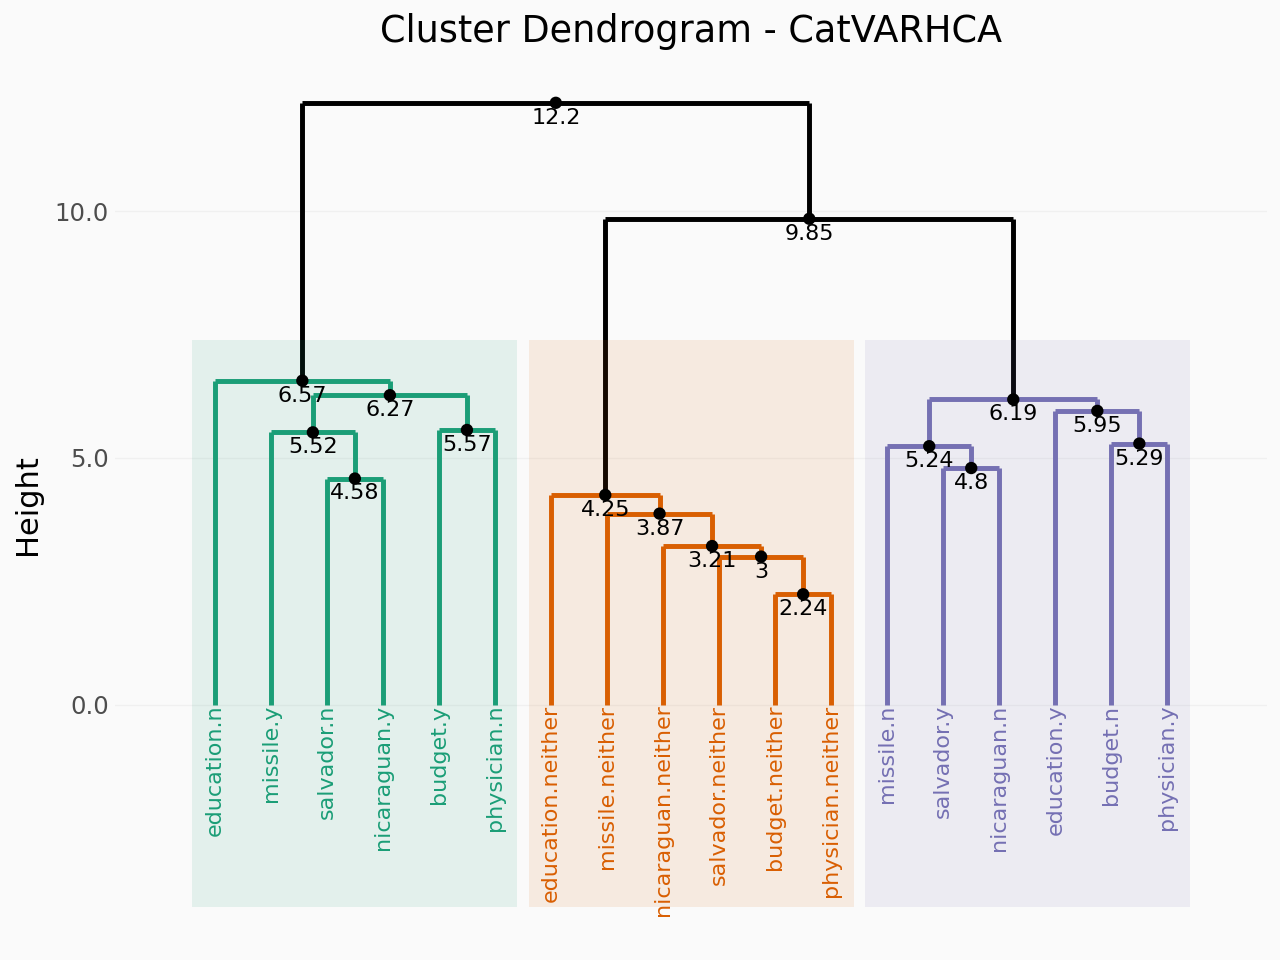

None


In [13]:
# dendrogram
from clustvartools import fviz_dend, fviz_height
p = fviz_dend(obj=clf,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_y=-0.1)
print(p.show())

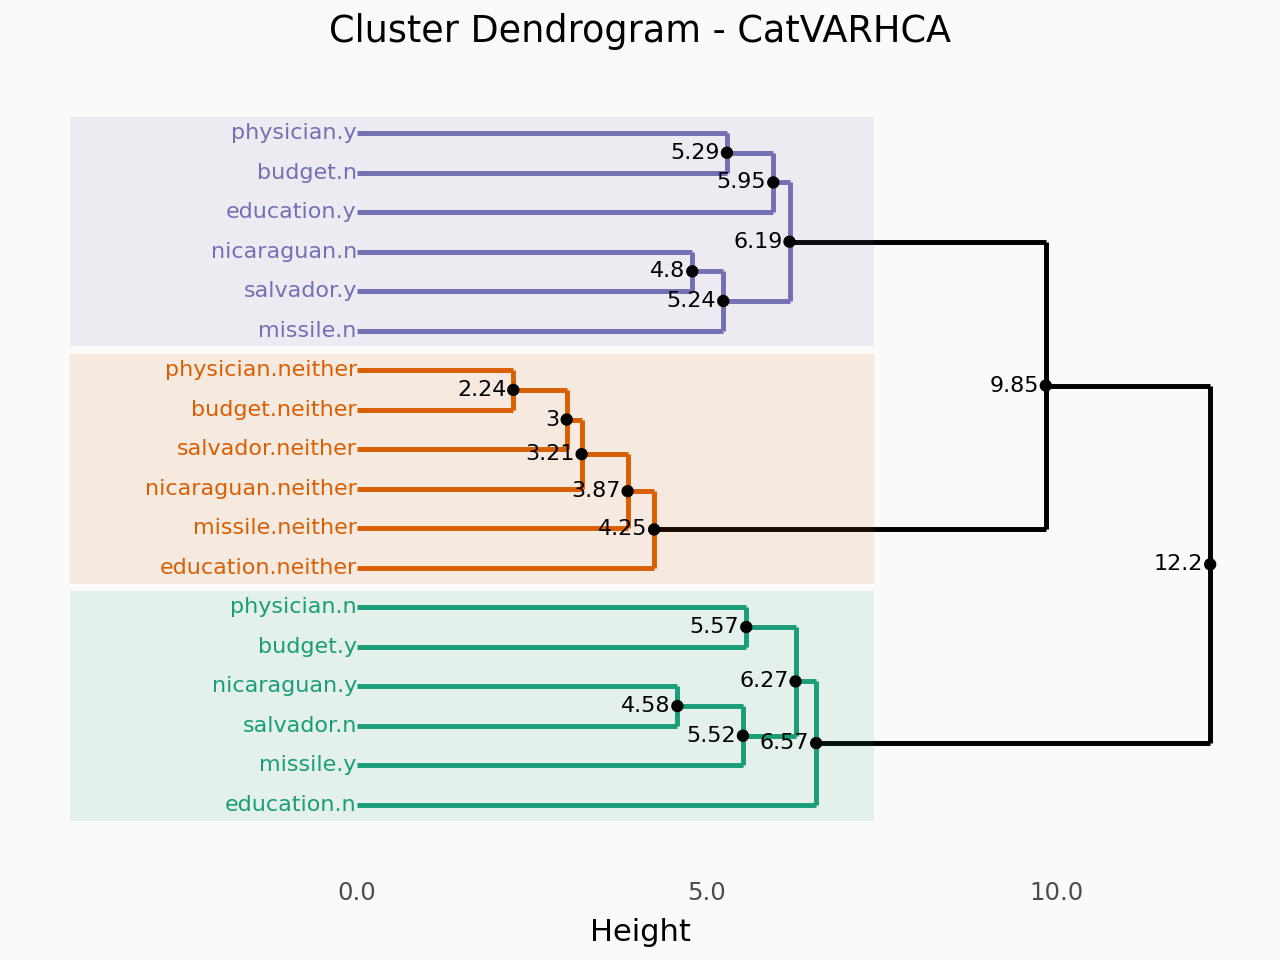

None


In [14]:
# horizon 
p = fviz_dend(obj=clf,
              horiz=True,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_x=-0.1)
print(p.show())

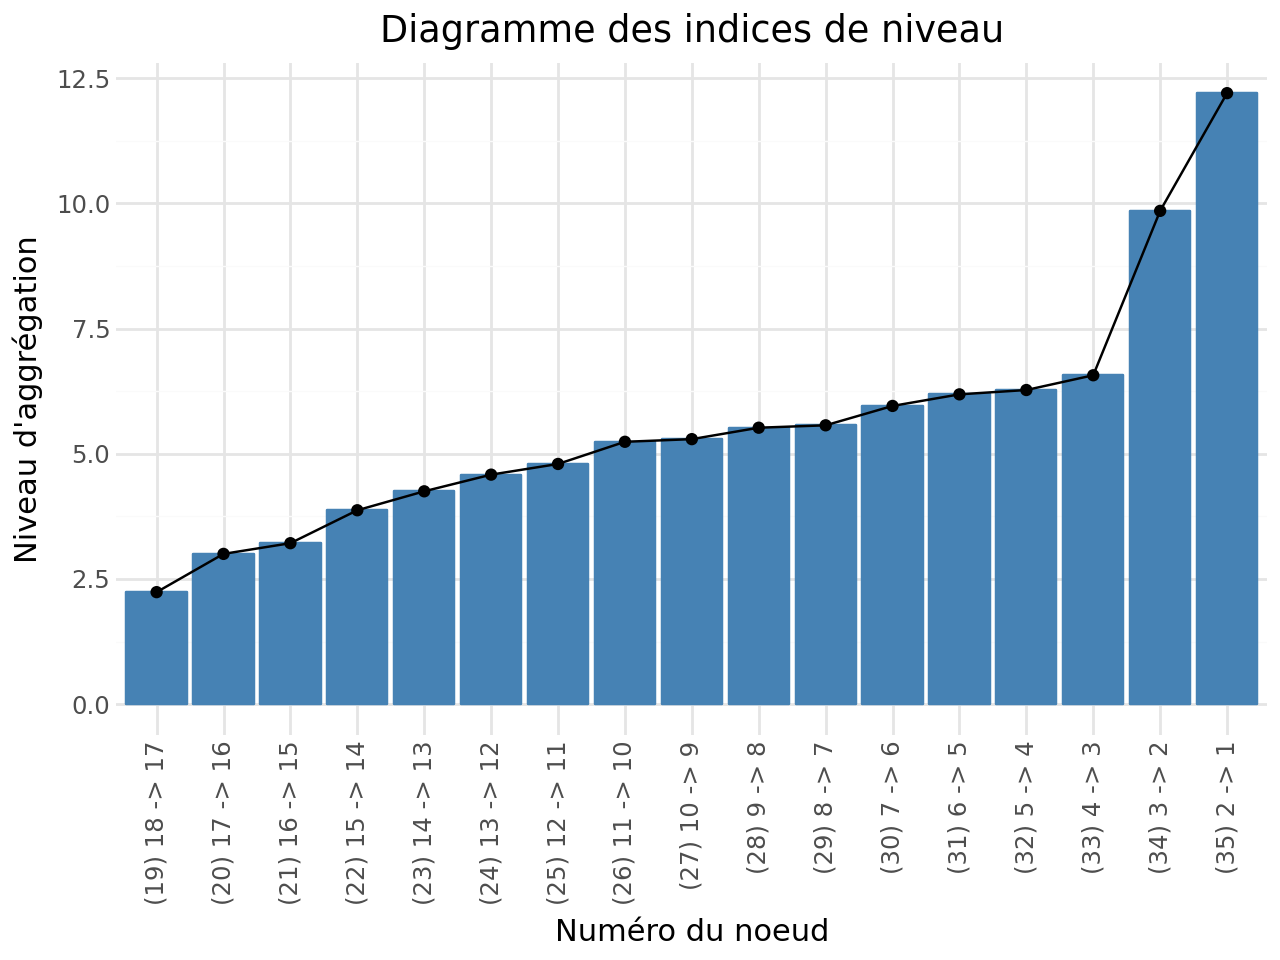

None


In [15]:
# graph of height
p = fviz_height(clf)
print(p.show())

## Supplementary levels informations

In [16]:
# supplementary levels informations
levels_sup_ = clf.levels_sup_
levels_sup_._fields

('cluster', 'dist', 'member')

### Cluster

In [17]:
# cluster
levels_sup_.cluster.to_frame()

,cluster
democrat,1
republican,3


### Cluster distance

In [18]:
# distance - supplementary levels
levels_sup_.dist

,1,2,3
democrat,5.682879,11.440894,13.654221
republican,13.558436,9.303164,5.445361


### Cluster member

In [19]:
# cluster member
levels_sup_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,Ratio (Own/Next)
0,democrat,1,5.682879,11.440894,0.496716
1,republican,3,5.445361,9.303164,0.585324


## Summary

In [20]:
# summary
from clustvartools import summary
summary(clf)

                     Clustering of Variables - CatVARHCA Results                     

Cluster Distance:
                         1        2        3
budget.n           13.4992   9.4991   5.0089
budget.neither     10.8442   2.7216   9.7854
budget.y            5.2233  11.2573  13.5657
physician.n         5.0128  11.1224  13.6654
physician.neither  10.7992   2.7216   9.8377
physician.y        13.6366   9.6549   4.6969
salvador.n          4.7894  10.3309  13.6574
salvador.neither   10.7962   2.9369   9.8778
salvador.y         13.7285  10.4355   4.6113
nicaraguan.n       13.6060   9.6818   4.7566

Cluster Members and Distance values:
            Variable Cluster Own Cluster Next Closest Ratio (Own/Next)
0           budget.n       3    5.008938     9.499134         0.527305
1     budget.neither       2    2.721556     9.785448         0.278123
2           budget.y       1    5.223275    11.257282         0.463991
3        physician.n       1    5.012771    11.122354         0.450693
4  phys

In [21]:
# markdown formatting
summary(clf,to_markdown=True)

                     Clustering of Variables - CatVARHCA Results                     

Cluster Distance:
                         1        2        3
-----------------  -------  -------  -------
budget.n           13.4992   9.4991   5.0089
budget.neither     10.8442   2.7216   9.7854
budget.y            5.2233  11.2573  13.5657
physician.n         5.0128  11.1224  13.6654
physician.neither  10.7992   2.7216   9.8377
physician.y        13.6366   9.6549   4.6969
salvador.n          4.7894  10.3309  13.6574
salvador.neither   10.7962   2.9369   9.8778
salvador.y         13.7285  10.4355   4.6113
nicaraguan.n       13.606    9.6818   4.7566

Cluster Members and Distance values:
    Variable             Cluster    Own Cluster    Next Closest    Ratio (Own/Next)
--  -----------------  ---------  -------------  --------------  ------------------
 0  budget.n                   3        5.00894         9.49913            0.527305
 1  budget.neither             2        2.72156         9.78545  